Some simple code for displaying some of the slices and their segmentation masks

In [31]:
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

In [32]:
from src.label_sessions.generate_mosaics import display_slice
from src.data import get_samples_df
from src.data import DicomDataset, VisualParams

In [33]:
data_path = Path('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11/final.csv')

In [34]:
vis_params = VisualParams(display_method = 'stack2', 
                    norm_method = 'min-max', 
                    masked_norm = True,
                    percentile_norm   = .02)

data_samples_df, person_ids = get_samples_df(data_path, include_edges = False)
train_dataset = DicomDataset(data_samples_df, vis_params = vis_params, person_ids = person_ids, summarize_name = 'bleh bleh')


Full Dataset has 6970 samples
final_label
0    5781
1    1189
Name: count, dtype: Int64
bleh bleh
----------------
{'pos': 1189, 'neg': 5781, 'total': 6970}
----------------



In [79]:
idxs = [80, 30, 50, 99]

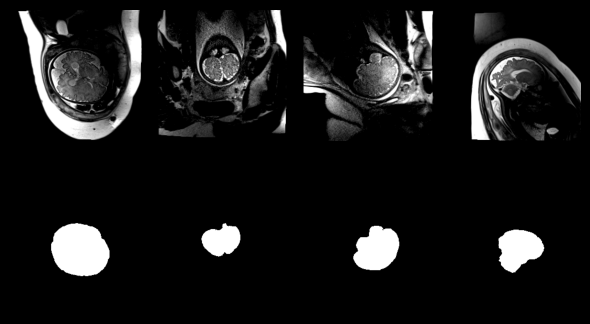

In [80]:

fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize = (6,4))
for i, idx in enumerate(idxs):
    img, mask = train_dataset[idx][0][0, :, :], train_dataset[idx][1]
    ax[0, i].imshow(img, cmap='grey', vmin=0, vmax = 1)
    ax[1, i].imshow(mask, cmap='grey', vmin=0, vmax = 1)

    ax[0, i].axis("off")
    ax[1, i].axis("off")

plt.tight_layout()
plt.savefig('segmentation.png')